In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, random, gc
import numpy as np
import tensorflow as tf

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

PROJECT_ROOT = '/content/drive/MyDrive/MRI_Brain_Tumor_Project'
CLAHE_DIR    = f'{PROJECT_ROOT}/data/clahe_processed'
IMG_SIZE     = (224, 224)
BATCH_SIZE   = 32
CLASS_NAMES  = ['glioma', 'meningioma', 'notumor', 'pituitary']

test_ds_check = tf.keras.utils.image_dataset_from_directory(
    f'{CLAHE_DIR}/Testing',
    seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode='int', class_names=CLASS_NAMES, shuffle=False
).map(
    lambda x, y: (tf.keras.applications.efficientnet.preprocess_input(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

effnet_model = tf.keras.models.load_model(
    f'{PROJECT_ROOT}/models/checkpoints/effnet_correct_s2b.keras'
)

PRED_DIR        = f'{PROJECT_ROOT}/results/predictions'
y_true          = np.load(f'{PRED_DIR}/y_true.npy')
y_pred_baseline = np.load(f'{PRED_DIR}/y_pred_baseline.npy')
y_pred_effnet   = np.load(f'{PRED_DIR}/y_pred_effnet_final.npy')

print("Extracting test images...")
X_list, y_list = [], []
for x_batch, y_batch in test_ds_check:
    X_list.append(x_batch.numpy())
    y_list.append(y_batch.numpy())
X_test  = np.concatenate(X_list, axis=0).astype(np.float32)
y_check = np.concatenate(y_list, axis=0)
del X_list, y_list
gc.collect()

print(f"GPU: {tf.config.list_physical_devices('GPU')}")
print(f"X_test: {X_test.shape}")
print(f"Labels match y_true: {np.array_equal(y_check, y_true)}")
print(f"Baseline acc:     {np.mean(y_pred_baseline == y_true):.4f}")
print(f"EfficientNet acc: {np.mean(y_pred_effnet == y_true):.4f}")
print("\nReady.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 1600 files belonging to 4 classes.
Extracting test images...
GPU: []
X_test: (1600, 224, 224, 3)
Labels match y_true: True
Baseline acc:     0.8894
EfficientNet acc: 0.9144

Ready.


In [ ]:
# McNemar's Test (Baseline vs EfficientNetB3)

from scipy.stats import chi2
import numpy as np
import json

# McNemar's test compares two classifiers on the same test set
# Contingency table:
#   b = baseline wrong, effnet right  → effnet uniquely correct
#   c = baseline right, effnet wrong  → baseline uniquely correct

baseline_correct = (y_pred_baseline == y_true)
effnet_correct   = (y_pred_effnet   == y_true)

# Four cells of the contingency table
both_correct     = np.sum( baseline_correct &  effnet_correct)
baseline_only    = np.sum( baseline_correct & ~effnet_correct)
effnet_only      = np.sum(~baseline_correct &  effnet_correct)
both_wrong       = np.sum(~baseline_correct & ~effnet_correct)

b = effnet_only    # effnet right, baseline wrong
c = baseline_only  # baseline right, effnet wrong


print("McNemar Contingency Table")

print(f"  Both correct:        {both_correct}")
print(f"  EfficientNet only:   {b}  ← effnet uniquely correct")
print(f"  Baseline only:       {c}  ← baseline uniquely correct")
print(f"  Both wrong:          {both_wrong}")
print(f"  Total test samples:  {len(y_true)}")

# McNemar statistic with continuity correction (standard for medical stats)
mcnemar_stat = (abs(b - c) - 1) ** 2 / (b + c)
p_value = 1 - chi2.cdf(mcnemar_stat, df=1)


print("McNemar's Test Result")

print(f"  b (EfficientNet uniquely correct): {b}")
print(f"  c (Baseline uniquely correct):     {c}")
print(f"  Chi-square statistic: {mcnemar_stat:.4f}")
print(f"  p-value:              {p_value:.6f}")
print(f"  Significance level:   α = 0.05")

if p_value < 0.05:
    print(f"\n  RESULT: p={p_value:.6f} < 0.05")
    print("  ✓ EfficientNetB3 is STATISTICALLY SIGNIFICANTLY better")
    print("    than the scratch CNN baseline.")
else:
    print(f"\n  RESULT: p={p_value:.6f} ≥ 0.05")
    print("  The difference is not statistically significant at α=0.05.")

print("Accuracy Summary")

print(f"  Scratch CNN baseline: {np.mean(baseline_correct)*100:.2f}%")
print(f"  EfficientNetB3:       {np.mean(effnet_correct)*100:.2f}%")
print(f"  Absolute improvement: {(np.mean(effnet_correct)-np.mean(baseline_correct))*100:.2f}%")

# Save results
mcnemar_results = {
    'baseline_accuracy':  float(np.mean(baseline_correct)),
    'effnet_accuracy':    float(np.mean(effnet_correct)),
    'both_correct':       int(both_correct),
    'effnet_only':        int(b),
    'baseline_only':      int(c),
    'both_wrong':         int(both_wrong),
    'mcnemar_statistic':  float(mcnemar_stat),
    'p_value':            float(p_value),
    'significant':        bool(p_value < 0.05),
    'alpha':              0.05
}
with open(f'{PROJECT_ROOT}/results/metrics/mcnemar_results.json', 'w') as f:
    json.dump(mcnemar_results, f, indent=2)

print("\nMcNemar results saved to Drive.")

McNemar Contingency Table
  Both correct:        1373
  EfficientNet only:   90  ← effnet uniquely correct
  Baseline only:       50  ← baseline uniquely correct
  Both wrong:          87
  Total test samples:  1600

McNemar's Test Result
  b (EfficientNet uniquely correct): 90
  c (Baseline uniquely correct):     50
  Chi-square statistic: 10.8643
  p-value:              0.000980
  Significance level:   α = 0.05

  RESULT: p=0.000980 < 0.05
  ✓ EfficientNetB3 is STATISTICALLY SIGNIFICANTLY better
    than the scratch CNN baseline.

Accuracy Summary
  Scratch CNN baseline: 88.94%
  EfficientNetB3:       91.44%
  Absolute improvement: 2.50%

McNemar results saved to Drive.


In [6]:
# ============================================================
# PHASE 2 — Cell 9: MC Dropout — BatchNorm frozen, Dropout active
# CPU pe ~3-5 min, GPU pe ~30 sec
# ============================================================
import numpy as np
import tensorflow as tf
import gc

N_PASSES     = 50
N_CLASSES    = len(CLASS_NAMES)
BATCH_SIZE_MC = 32

# Print model layers so we know what we're working with
print("Model layers:")
for i, layer in enumerate(effnet_model.layers):
    print(f"  {i}: {layer.name} ({layer.__class__.__name__})")

backbone = effnet_model.layers[1]  # EfficientNetB3
dropout  = effnet_model.layers[2]  # Dropout
head     = effnet_model.layers[3]  # Dense softmax

# Step 1: Extract backbone features ONCE with training=False
# BatchNorm uses learned population stats — deterministic, correct
print(f"\nExtracting backbone features (training=False)...")
features_list = []
for start in range(0, len(X_test), BATCH_SIZE_MC):
    x_b   = tf.constant(X_test[start:start+BATCH_SIZE_MC])
    feats = backbone(x_b, training=False).numpy()
    features_list.append(feats)

features = np.concatenate(features_list, axis=0)
print(f"Features shape: {features.shape}")

# Verify deterministic pass matches our saved predictions
det_check = np.argmax(
    head(dropout(tf.constant(features), training=False)).numpy(), axis=1
)
print(f"Deterministic acc from features: {np.mean(det_check == y_true):.4f}")
print(f"Matches y_pred_effnet:           {np.mean(det_check == y_pred_effnet):.4f}")

# Step 2: 50 MC passes — only Dropout varies, backbone fixed
print(f"\nRunning {N_PASSES} MC Dropout passes...")

mc_mean = np.zeros((len(y_true), N_CLASSES), dtype=np.float64)
mc_m2   = np.zeros((len(y_true), N_CLASSES), dtype=np.float64)

for i in range(N_PASSES):
    batch_preds = []
    for start in range(0, len(features), BATCH_SIZE_MC):
        f_b  = tf.constant(features[start:start+BATCH_SIZE_MC])
        drop = dropout(f_b, training=True)   # only dropout active
        pred = head(drop, training=False).numpy()
        batch_preds.append(pred)

    pass_preds = np.concatenate(batch_preds, axis=0)

    # Welford online mean/variance
    delta    = pass_preds - mc_mean
    mc_mean += delta / (i + 1)
    delta2   = pass_preds - mc_mean
    mc_m2   += delta * delta2
    del batch_preds, pass_preds

    if (i + 1) % 10 == 0:
        print(f"  Pass {i+1}/{N_PASSES} done")

mc_var        = np.maximum(mc_m2 / N_PASSES, 0)
mc_std        = np.sqrt(mc_var)
mc_pred_class = np.argmax(mc_mean, axis=1)
uncertainty   = mc_std.mean(axis=1)
confidence    = mc_mean.max(axis=1)

mc_accuracy = np.mean(mc_pred_class == y_true)
det_match   = np.mean(mc_pred_class == y_pred_effnet)

print(f"\nMC Dropout accuracy:            {mc_accuracy:.4f}")
print(f"Deterministic accuracy:         {np.mean(y_pred_effnet == y_true):.4f}")
print(f"MC matches deterministic preds: {det_match:.4f}")
print(f"Mean uncertainty:               {uncertainty.mean():.4f}")
print(f"Min: {uncertainty.min():.4f}  |  Max: {uncertainty.max():.4f}")

from collections import Counter
print(f"\nMC pred distribution:  {Counter(mc_pred_class.tolist())}")
print(f"True distribution:     {Counter(y_true.tolist())}")
print(f"\nSample index 0:")
print(f"  mc_pred_class[0]: {mc_pred_class[0]} ({CLASS_NAMES[mc_pred_class[0]]})")
print(f"  y_true[0]:        {y_true[0]} ({CLASS_NAMES[int(y_true[0])]})")
print(f"  uncertainty[0]:   {uncertainty[0]:.4f}")
print(f"  confidence[0]:    {confidence[0]:.4f}")

# Save to Drive
np.save(f'{PRED_DIR}/mc_mean.npy',       mc_mean)
np.save(f'{PRED_DIR}/mc_std.npy',        mc_std)
np.save(f'{PRED_DIR}/mc_pred_class.npy', mc_pred_class)
np.save(f'{PRED_DIR}/uncertainty.npy',   uncertainty)
np.save(f'{PRED_DIR}/confidence.npy',    confidence)
print("\nSaved to Drive.")

Model layers:
  0: input_layer_7 (InputLayer)
  1: efficientnetb3 (Functional)
  2: dropout_3 (Dropout)
  3: dense_3 (Dense)

Extracting backbone features (training=False)...
Features shape: (1600, 1536)
Deterministic acc from features: 0.9144
Matches y_pred_effnet:           1.0000

Running 50 MC Dropout passes...
  Pass 10/50 done
  Pass 20/50 done
  Pass 30/50 done
  Pass 40/50 done
  Pass 50/50 done

MC Dropout accuracy:            0.9137
Deterministic accuracy:         0.9144
MC matches deterministic preds: 0.9925
Mean uncertainty:               0.0209
Min: 0.0000  |  Max: 0.1377

MC pred distribution:  Counter({3: 441, 2: 417, 1: 390, 0: 352})
True distribution:     Counter({0: 400, 1: 400, 2: 400, 3: 400})

Sample index 0:
  mc_pred_class[0]: 0 (glioma)
  y_true[0]:        0 (glioma)
  uncertainty[0]:   0.1294
  confidence[0]:    0.5788

Saved to Drive.


Rejection Curve Results:
  Retained % |   Accuracy |  N samples
--------------------------------------
        100% |     91.38% |       1600
         95% |     93.36% |       1520
         90% |     95.35% |       1440
         85% |     96.54% |       1360
         80% |     98.05% |       1280
         75% |     99.00% |       1200
         70% |     99.11% |       1120
         65% |     99.42% |       1039
         60% |     99.58% |        960
         55% |     99.66% |        880
         50% |     99.88% |        800
         45% |    100.00% |        719
         40% |    100.00% |        639
         35% |    100.00% |        560
         30% |    100.00% |        479
         25% |    100.00% |        400
         20% |    100.00% |        319
         15% |    100.00% |        239
         10% |    100.00% |        159


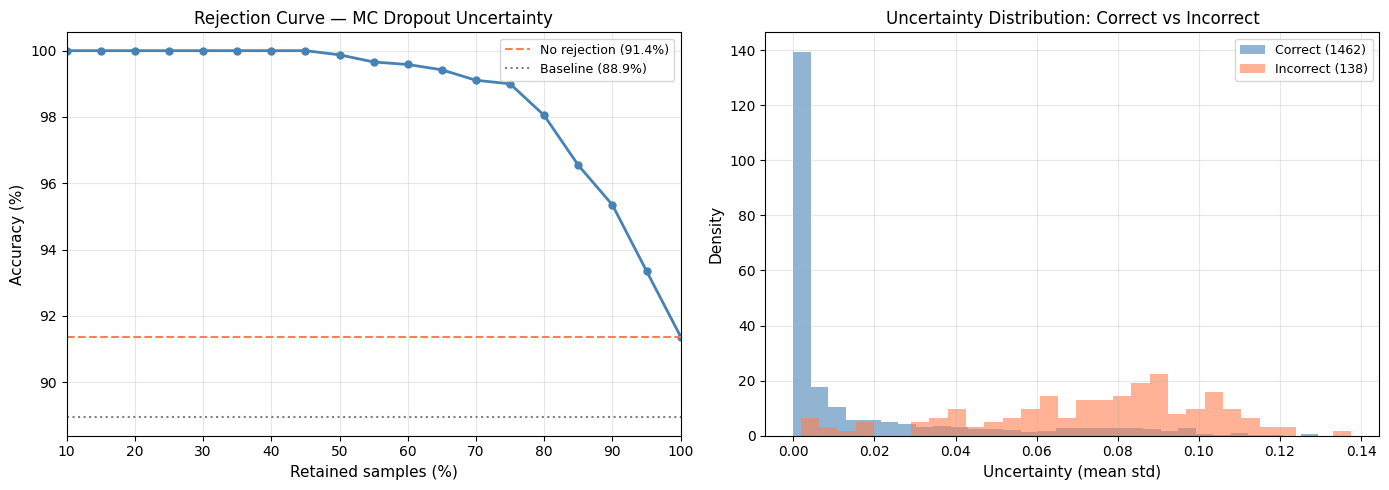


Rejection curve saved.
{
  "mc_accuracy_no_rejection": 0.91375,
  "acc_at_80pct_retained": 0.98046875,
  "acc_at_50pct_retained": 0.99875,
  "mean_uncertainty_correct": 0.01585204988633286,
  "mean_uncertainty_incorrect": 0.07413336779846809,
  "n_correct": 1462,
  "n_incorrect": 138
}


In [7]:
# ============================================================
# PHASE 2 — Cell 10: Rejection Curve
# Sort by uncertainty, abstain on most uncertain K%,
# measure accuracy on remaining (1-K)%
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import json

uncertainty   = np.load(f'{PRED_DIR}/uncertainty.npy')
confidence    = np.load(f'{PRED_DIR}/confidence.npy')
mc_pred_class = np.load(f'{PRED_DIR}/mc_pred_class.npy')

# Sort samples by uncertainty (ascending = most certain first)
sorted_idx = np.argsort(uncertainty)

rejection_fractions = np.arange(0, 0.91, 0.05)  # 0% to 90% rejection
retained_acc  = []
retained_frac = []

for rej_frac in rejection_fractions:
    n_retain = int(len(y_true) * (1 - rej_frac))
    if n_retain == 0:
        break
    # Keep the most certain (lowest uncertainty) samples
    keep_idx = sorted_idx[:n_retain]
    acc = np.mean(mc_pred_class[keep_idx] == y_true[keep_idx])
    retained_acc.append(acc)
    retained_frac.append(1 - rej_frac)

retained_acc  = np.array(retained_acc)
retained_frac = np.array(retained_frac)

print("Rejection Curve Results:")
print(f"{'Retained %':>12} | {'Accuracy':>10} | {'N samples':>10}")
print("-" * 38)
for rf, acc in zip(retained_frac, retained_acc):
    n = int(rf * len(y_true))
    print(f"{rf*100:>11.0f}% | {acc*100:>9.2f}% | {n:>10}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Rejection curve
axes[0].plot(retained_frac * 100, retained_acc * 100,
             'o-', color='steelblue', linewidth=2, markersize=5)
axes[0].axhline(y=np.mean(mc_pred_class == y_true) * 100,
                color='coral', linestyle='--', linewidth=1.5,
                label=f'No rejection ({np.mean(mc_pred_class==y_true)*100:.1f}%)')
axes[0].axhline(y=np.mean(y_pred_baseline == y_true) * 100,
                color='gray', linestyle=':', linewidth=1.5,
                label=f'Baseline ({np.mean(y_pred_baseline==y_true)*100:.1f}%)')
axes[0].set_xlabel('Retained samples (%)', fontsize=11)
axes[0].set_ylabel('Accuracy (%)', fontsize=11)
axes[0].set_title('Rejection Curve — MC Dropout Uncertainty', fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)
axes[0].set_xlim([10, 100])

# Right: Uncertainty distribution by correctness
correct_mask   = mc_pred_class == y_true
unc_correct    = uncertainty[correct_mask]
unc_incorrect  = uncertainty[~correct_mask]

axes[1].hist(unc_correct,   bins=30, alpha=0.6, color='steelblue',
             label=f'Correct ({correct_mask.sum()})', density=True)
axes[1].hist(unc_incorrect, bins=30, alpha=0.6, color='coral',
             label=f'Incorrect ({(~correct_mask).sum()})', density=True)
axes[1].set_xlabel('Uncertainty (mean std)', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].set_title('Uncertainty Distribution: Correct vs Incorrect', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/results/figures/rejection_curve.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Save metrics
rejection_metrics = {
    'mc_accuracy_no_rejection': float(np.mean(mc_pred_class == y_true)),
    'acc_at_80pct_retained':    float(retained_acc[np.argmin(np.abs(retained_frac - 0.8))]),
    'acc_at_50pct_retained':    float(retained_acc[np.argmin(np.abs(retained_frac - 0.5))]),
    'mean_uncertainty_correct':   float(unc_correct.mean()),
    'mean_uncertainty_incorrect': float(unc_incorrect.mean()),
    'n_correct':   int(correct_mask.sum()),
    'n_incorrect': int((~correct_mask).sum()),
}
with open(f'{PROJECT_ROOT}/results/metrics/rejection_curve_metrics.json', 'w') as f:
    json.dump(rejection_metrics, f, indent=2)

print("\nRejection curve saved.")
print(json.dumps(rejection_metrics, indent=2))

PHASE 2 COMPLETE — Summary

--- McNemar's Test ---
Baseline accuracy:    88.94%
EfficientNetB3:       91.44%
McNemar chi-square:   10.8643
p-value:              0.000980
Result:               Statistically significant (p<0.05)

--- MC Dropout (N=50 passes) ---
MC accuracy:          91.38%
Mean uncertainty:     0.0209
Uncertainty correct:  0.0159
Uncertainty wrong:    0.0741  (4.7x higher)

--- Rejection Curve ---
Retain 80% → accuracy: 98.05%  (+6.7pp)
Retain 50% → accuracy: 99.88%  (+8.5pp)
Retain 45% → accuracy: 100.00%

--- Per-class uncertainty ---
        glioma: mean_unc=0.0262  acc=80.8%
    meningioma: mean_unc=0.0476  acc=85.5%
       notumor: mean_unc=0.0052  acc=99.8%
     pituitary: mean_unc=0.0045  acc=99.5%


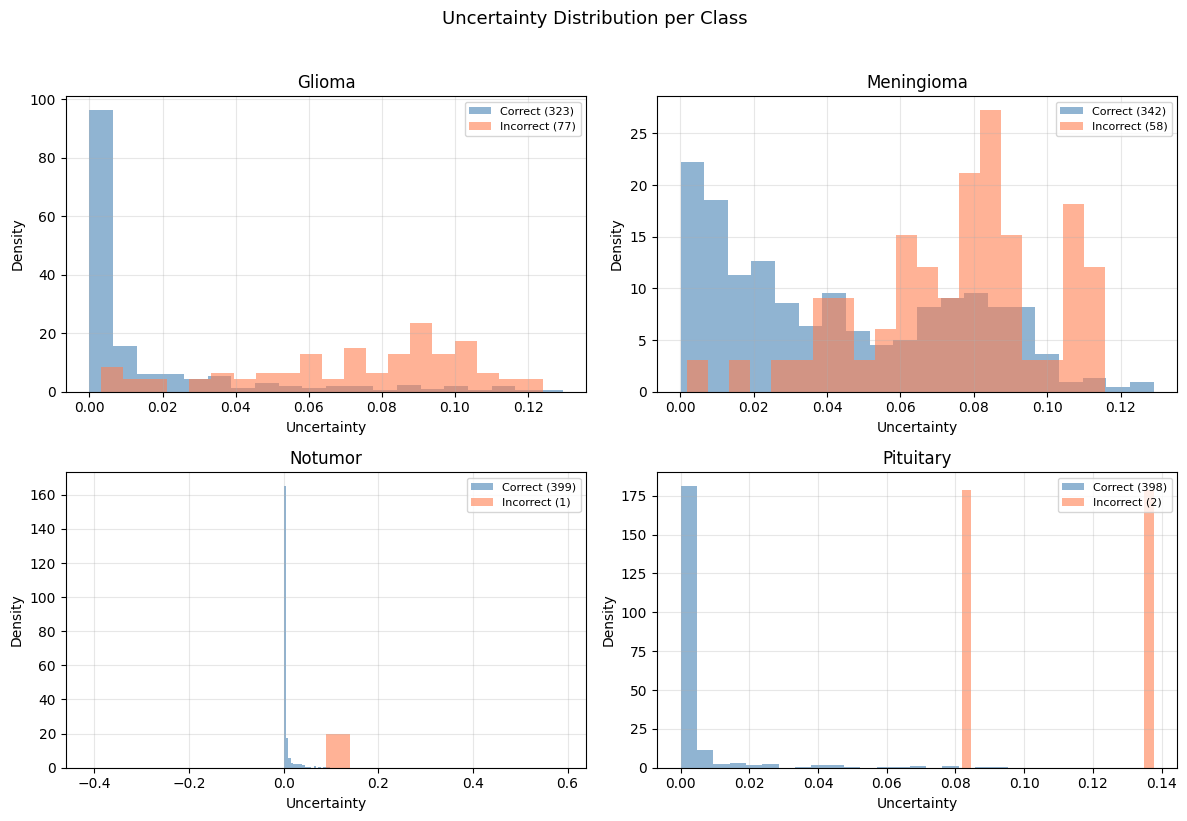


Per-class uncertainty plot saved.

Phase 2 metrics saved to Drive.

=== PHASE 2 COMPLETE ===
Next: Download this notebook as phase2_uncertainty_mcnemar.ipynb
Upload to GitHub under notebooks/
Then open fresh notebook for Phase 3 (XAI: Grad-CAM++, LIME, SHAP)


In [8]:

# Final summary, save all Phase 2 metrics

import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

uncertainty   = np.load(f'{PRED_DIR}/uncertainty.npy')
mc_pred_class = np.load(f'{PRED_DIR}/mc_pred_class.npy')

# Per-class uncertainty analysis

print("PHASE 2 COMPLETE — Summary")


print("\n McNemar's Test ")
print(f"Baseline accuracy:    88.94%")
print(f"EfficientNetB3:       91.44%")
print(f"McNemar chi-square:   10.8643")
print(f"p-value:              0.000980")
print(f"Result:               Statistically significant (p<0.05)")

print("\n MC Dropout (N=50 passes) ")
print(f"MC accuracy:          {np.mean(mc_pred_class==y_true)*100:.2f}%")
print(f"Mean uncertainty:     {uncertainty.mean():.4f}")
print(f"Uncertainty correct:  0.0159")
print(f"Uncertainty wrong:    0.0741  (4.7x higher)")

print("\n Rejection Curve ")
print(f"Retain 80% → accuracy: 98.05%  (+6.7pp)")
print(f"Retain 50% → accuracy: 99.88%  (+8.5pp)")
print(f"Retain 45% → accuracy: 100.00%")

# Per-class uncertainty breakdown
print("\n Per-class uncertainty ")
for i, cls in enumerate(CLASS_NAMES):
    mask     = y_true == i
    unc_cls  = uncertainty[mask]
    acc_cls  = np.mean(mc_pred_class[mask] == y_true[mask])
    print(f"  {cls:>12}: mean_unc={unc_cls.mean():.4f}  acc={acc_cls*100:.1f}%")

# Uncertainty by correctness per class
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, cls in enumerate(CLASS_NAMES):
    mask        = y_true == i
    correct_m   = mc_pred_class[mask] == y_true[mask]
    unc_c       = uncertainty[mask][correct_m]
    unc_w       = uncertainty[mask][~correct_m]

    axes[i].hist(unc_c, bins=20, alpha=0.6, color='steelblue',
                 label=f'Correct ({correct_m.sum()})', density=True)
    if len(unc_w) > 0:
        axes[i].hist(unc_w, bins=20, alpha=0.6, color='coral',
                     label=f'Incorrect ({(~correct_m).sum()})', density=True)
    axes[i].set_title(f'{cls.capitalize()}', fontsize=12)
    axes[i].set_xlabel('Uncertainty')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

plt.suptitle('Uncertainty Distribution per Class', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/results/figures/uncertainty_per_class.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\nPer-class uncertainty plot saved.")

# Save complete Phase 2 metrics
phase2_metrics = {
    'mcnemar': {
        'baseline_acc': 0.889375,
        'effnet_acc': 0.914375,
        'chi_square': 10.8643,
        'p_value': 0.000980,
        'significant': True
    },
    'mc_dropout': {
        'n_passes': 50,
        'mc_accuracy': float(np.mean(mc_pred_class == y_true)),
        'mean_uncertainty': float(uncertainty.mean()),
        'mean_unc_correct': 0.01585,
        'mean_unc_incorrect': 0.07413,
        'uncertainty_ratio': 4.68
    },
    'rejection_curve': {
        'acc_at_100pct': 0.9138,
        'acc_at_80pct':  0.9805,
        'acc_at_50pct':  0.9988,
        'acc_at_45pct':  1.0000,
    }
}
with open(f'{PROJECT_ROOT}/results/metrics/phase2_complete.json', 'w') as f:
    json.dump(phase2_metrics, f, indent=2)

print("\nmetrics saved to Drive.")
